>
> # Scenario analysis - Two-dimensional
>
> ## Visualisation
>
-----
Analyse the effect of variables on ridesourcing system performance

In [2]:
%load_ext autoreload
%autoreload 2
import os, zipfile
from dotmap import DotMap
import pandas as pd
import matplotlib.pyplot as plt
import math
import numpy as np
import json
from scipy.stats import t
import re
import seaborn as sns
from scenarios import *
from scenarios_2D import *
from plot_func import *

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [3]:
# Enter variable and data type
# variable = {"name": "gini", "sym": "$G$", "int": False}
variable_1 = {"name": "nP", "sym": "$K$", "int": True}
variable_2 = {"name": "nV", "sym": "$N$", "int": True}

In [4]:
# Loop through zip files
dir_name = os.path.join(os.getcwd(),'input',variable_1["name"]+'-'+variable_2["name"])
# dir_name = os.path.join(os.getcwd(),'input',variable["name"])
res, micro, params, drivers, requests, var_val = load_results_2d(dir_name)

# Find variable values that have been tested
vals, scn = find_vals_2d(var_val, variable_1, variable_2)

# Compute additional (aggregated) day-to-day indicators, incl. standard deviations, properties of agent groups, and relative indicators
res = add_indicators(micro, params, drivers, requests, res)

In [5]:
vals_1 = set([i.split('_', 1)[0] for i in vals])
vals_2 = set([i.split('_', 1)[1] for i in vals])

abc_1 = set(map(int, [i.split('_', 1)[0] for i in vals]))
abc_2 = set(map(int, [i.split('_', 1)[1] for i in vals]))

In [6]:
# Find equilibrium values for all runs
conv_repl = determine_eql(res, params)
conv_repl.head(10)

,t_sup*,perc_inc_reg*,t_dem*,perc_wait*,t*,converged
0,58,64.877729,37,413.092450,58,True
1,66,62.086715,26,421.452409,66,True
2,75,59.094899,37,407.682577,75,True
3,83,58.110376,29,398.101365,83,True
4,119,58.931897,31,423.583293,119,True
5,123,80.053691,34,534.734156,123,True
6,122,93.457236,39,672.068067,122,True
7,10,171.971689,35,689.563603,35,True
8,55,89.136569,34,695.884162,55,True
9,199,80.654276,37,586.940419,199,False


In [7]:
# Convert indicators of individual runs to indicators for scenarios
eql_runs, eql_scn, d2d, params_scn = runs_to_scenarios(res, params, vals, scn)

Sufficient number of replications: 5/1 for scenario 15000_1000
Sufficient number of replications: 5/2 for scenario 15000_125
Sufficient number of replications: 5/1 for scenario 15000_1500
Sufficient number of replications: 5/1 for scenario 15000_2000
Sufficient number of replications: 5/2 for scenario 15000_250
Sufficient number of replications: 5/2 for scenario 15000_2500
Sufficient number of replications: 5/3 for scenario 15000_500
Sufficient number of replications: 5/1 for scenario 30000_1000
Sufficient number of replications: 5/3 for scenario 30000_125
Sufficient number of replications: 5/1 for scenario 30000_1500
Sufficient number of replications: 5/1 for scenario 30000_2000
Sufficient number of replications: 5/2 for scenario 30000_250
Sufficient number of replications: 5/1 for scenario 30000_2500
Sufficient number of replications: 5/1 for scenario 30000_500
Sufficient number of replications: 5/3 for scenario 3750_1000
Sufficient number of replications: 5/3 for scenario 3750_1500


In [8]:
# Create d2d statistics
res_scn = d2d_stats(d2d, vals, res)

In [9]:
eql_scn.dem.head(5)

,inform,requests,gets_offer,accepts_offer,mean_wait,corr_mean_wait,perc_wait,perc_wait_req,bike,car,pt,vot_inf,vot_req,std_perc_wait,std_exp_wait,std_corr_wait,std_perc_wait_req,GC_diff
scenario,,,,,,,,,,,,,,,,,,
15000_1000,3664.8,178.12,0.999204,177.96,271.052861,272.180110,455.051257,273.025546,2517.48,751.92,217.28,19.099931,22.981051,789.086642,197.661230,199.872693,131.781493,-2722.740787
15000_125,3664.8,118.04,0.987699,116.56,435.136426,451.078667,750.039796,420.921274,2563.44,761.28,222.04,19.099931,20.356075,1115.121983,286.344292,313.105639,183.043004,-2149.707614
15000_1500,3664.8,181.88,1.000000,181.88,273.231368,273.231368,430.668906,261.586188,2517.84,745.12,219.96,19.099931,22.993205,759.064891,198.152304,198.152304,120.963337,-2789.336194
15000_2000,3664.8,193.28,1.000000,193.28,255.633003,255.633003,404.773037,244.289251,2508.80,745.88,216.84,19.099931,23.316977,730.785754,183.781720,183.781720,113.986782,-2891.532484
15000_250,3664.8,138.72,0.996145,138.16,385.432340,390.592570,624.757035,355.806026,2534.04,768.72,223.32,19.099931,21.341447,997.520042,264.430847,274.146905,162.441050,-2416.430888


In [10]:
eql_scn.sup.head(5)

,inform,regist,particip,mean_perc_inc,mean_perc_inc_ptcp,mean_perc_inc_reg,mean_exp_inc,rel_perc_inc,rel_perc_inc_reg,rel_perc_inc_ptcp,std_perc_inc,std_exp_inc,std_perc_inc_reg,std_perc_inc_ptcp,res_wage_inf,res_wage_reg,res_wage_ptcp,new_regist,deregist,surplus
scenario,,,,,,,,,,,,,,,,,,,,
15000_1000,1000.0,44.48,17.24,59.456035,60.432018,60.160987,58.442603,0.448248,0.929188,1.685560,5.044989,18.380643,6.744340,6.917782,202.567751,137.117571,39.444989,2.40,2.36,-588.608636
15000_125,125.0,12.00,7.60,79.569970,79.507466,79.370259,79.566957,0.616892,1.408536,1.818173,6.763486,14.198958,5.831225,5.437280,196.046002,96.604775,49.089259,0.44,0.36,-21.825098
15000_1500,1500.0,55.64,17.44,58.847443,60.056727,58.430955,58.942687,0.442776,0.834971,1.737254,4.990258,20.641645,6.598686,7.684397,202.536002,156.584991,37.504964,3.16,3.48,-757.516443
15000_2000,2000.0,72.52,20.84,53.921740,54.683153,54.900370,53.135255,0.406122,0.770513,1.676540,5.433849,21.144011,14.404773,7.730254,201.650453,153.153477,35.336863,4.44,3.96,-1091.376972
15000_250,250.0,17.48,10.08,74.476752,74.703163,74.474458,72.635393,0.555575,1.333672,1.847508,6.133219,15.725739,5.901732,5.678766,205.036685,109.135579,45.838415,0.72,0.84,-91.626014


In [11]:
eql_scn.plf.head(5)

,profit
15000_1000,447.930066
15000_125,292.578393
15000_1500,459.587881
15000_2000,494.129360
15000_250,346.544699


In [12]:
# KPIs
kpis_sup = eql_scn.sup.columns
kpis_dem = eql_scn.dem.columns
kpis_plf = ['profit']

In [13]:
# Add scenario values as columns to df
eql_scn.sup = add_scn_vals(eql_scn.sup, variable_1, variable_2)
eql_scn.dem = add_scn_vals(eql_scn.dem, variable_1, variable_2)
eql_scn.plf = add_scn_vals(eql_scn.plf, variable_1, variable_2)

# eql_scn.plf[variable_1["name"]] = eql_scn.plf.index.str.split('_').str.get(0).astype(int)
# eql_scn.plf[variable_2["name"]] = eql_scn.plf.index.str.split('_').str.get(1).astype(int)
# eql_scn.index.name = 'scenario'

# # Add missing scenarios to df as nan's
# scn_names = []
# for val_1 in vals_1:
#     for val_2 in vals_2:
#         scn_name = str(val_1)+'_'+str(val_2)
#         scn_names.append(scn_name)
#         if scn_name not in eql_scn.plf.index:
#             eql_scn.plf = eql_scn.plf.append(pd.Series(data={'profit': np.nan,'nP': int(val_1), 'nV': int(val_2)}, name = scn_name), ignore_index=False)

# eql_scn.plf = eql_scn.plf.sort_values(["nP", "nV"])
# eql_scn.plf = eql_scn.plf.set_index(['nP','nV'])
# eql_scn.plf = eql_scn.plf.unstack(level=-1)
# eql_scn.plf.style.background_gradient(axis=None)

In [14]:
# # eql_scn.plf = eql_scn.plf.pivot(index='nP', columns='nV', values='profit')
# # sns.heatmap(data)
# sns.heatmap(eql_scn.plf.pivot(index='nP', columns='nV', values='profit'))
# plt.show()

In [15]:
# Find societal value
eql_scn.soc = eql_scn.sup.surplus + eql_scn.dem.GC_diff + eql_scn.plf.profit
eql_scn.soc = pd.DataFrame(eql_scn.soc.values, index = vals, columns = ['soc_value'])
eql_scn.soc = add_scn_vals(eql_scn.soc, variable_1, variable_2)

Text(0.5, 1.0, 'soc_value')

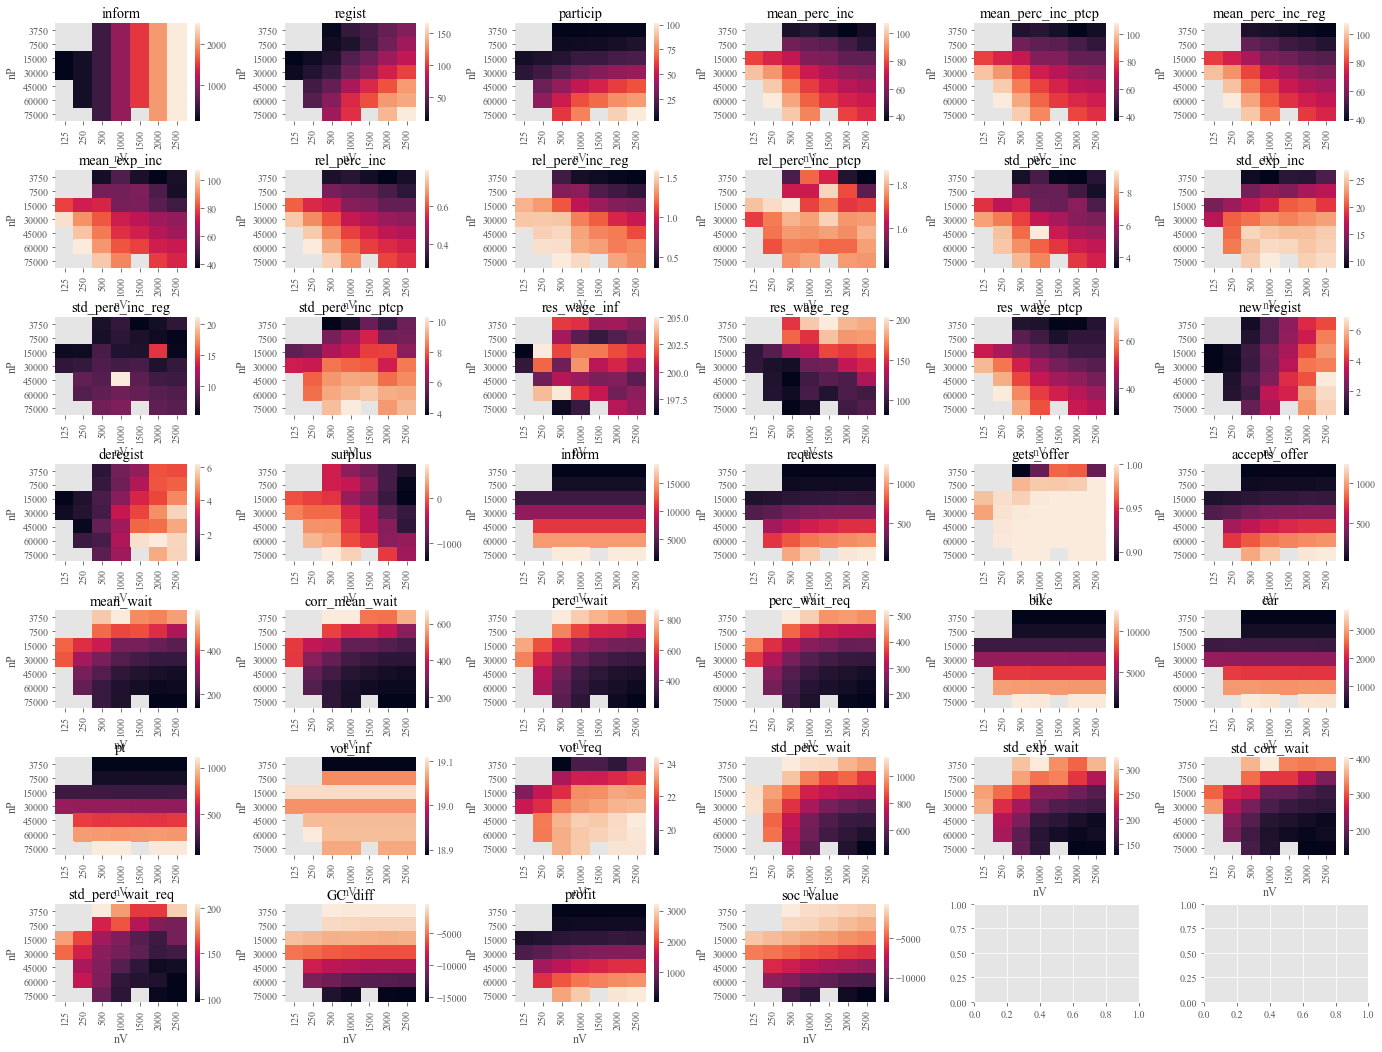

In [16]:
# Create pivot tables (incl. missing scenarios as NaNs)
fig, axes = plt.subplots(7, 6, figsize = [24,18])
    # plt.subplots_adjust(top=.9, bottom=.1, hspace=.1, left=.1, right=.9, wspace=.1)
fig.subplots_adjust(hspace=.5, wspace=0.4, left=.12, right=.88)

# sns.heatmap(eql_scn.sup.pivot(index='nP', columns='nV', values = 'inform'), ax=axes[0,0])
# axes[0, 1] = sns.heatmap(eql_scn.sup.pivot(index='nP', columns='nV', values = 'regist'))

i = 0
j = 0
for kpi in kpis_sup:
    axes[j, i] = sns.heatmap(eql_scn.sup.pivot(index='nP', columns='nV', values = kpi), ax=axes[j,i])
    axes[j, i].set_title(kpi)
    i += 1
    if i > 5:
        i = 0
        j += 1

for kpi in kpis_dem:
    axes[j, i] = sns.heatmap(eql_scn.dem.pivot(index='nP', columns='nV', values = kpi), ax=axes[j,i])
    axes[j, i].set_title(kpi)
    i += 1
    if i > 5:
        i = 0
        j += 1

for kpi in kpis_plf:
    axes[j, i] = sns.heatmap(eql_scn.plf.pivot(index='nP', columns='nV', values = kpi), ax=axes[j,i])
    axes[j, i].set_title(kpi)
    i += 1
    if i > 5:
        i = 0
        j += 1
        
axes[j, i] = sns.heatmap(eql_scn.soc.pivot(index='nP', columns='nV', values = 'soc_value'), ax=axes[j,i])
axes[j, i].set_title('soc_value')
# kokos = eql_scn.sup.pivot(index='nP', columns='nV', values=['inform','regist'])
# sns.heatmap(data)
# sns.heatmap(kokos)
# plt.show()

In [17]:
# Plot all indicators in one graph
fig = plot_multi_graph(res_scn, vals, variable)
fig.savefig(os.path.join(os.getcwd(),"plots",variable["name"], variable["name"] + '_multi_fig.jpg'),dpi=300,bbox_inches='tight')

NameError: name 'variable' is not defined

In [ ]:
# Plot an individual indicator
plot_inform = res_scn.sup.inform.plot()
plot_inform.set_ylabel("Volume of informed drivers")
plot_inform

In [ ]:
# kpi_eq.informed_drivers = round(kpi_eq.informed_drivers).astype(int)
# kpi_eq.regist_drivers = round(kpi_eq.regist_drivers).astype(int)
# kpi_eq.particip_drivers = round(kpi_eq.particip_drivers).astype(int)
# kpi_eq.requests = round(kpi_eq.requests).astype(int)
# kpi_eq.mean_perc_inc = round(kpi_eq.mean_perc_inc,2)
# kpi_eq.std_perc_inc = round(kpi_eq.std_perc_inc,2)
# kpi_eq.mean_exp_inc = round(kpi_eq.mean_exp_inc,2)
# kpi_eq.std_exp_inc = round(kpi_eq.std_exp_inc,2)
# kpi_eq.service_rate = round(kpi_eq.service_rate,1)
# kpi_eq.mean_wait_time = round(kpi_eq.mean_wait_time).astype(int)
# kpi_eq.exp_pure_wait = round(kpi_eq.exp_pure_wait).astype(int)
# kpi_eq.exp_wait_time = round(kpi_eq.exp_wait_time).astype(int)
# kpi_eq.std_perc_wait = round(kpi_eq.std_perc_wait).astype(int)
# kpi_eq.std_exp_wait = round(kpi_eq.std_exp_wait).astype(int)
# kpi_eq.std_corr_exp_wait = round(kpi_eq.std_corr_exp_wait).astype(int)
# kpi_eq.plf_profit = round(kpi_eq.plf_profit).astype(int)
# # kpi_eq = kpi_eq.drop(['perc_pax_reject'],axis=1)
# kpi_eq = kpi_eq[['informed_drivers','regist_drivers','particip_drivers', 'requests','mean_perc_inc','std_perc_inc','mean_exp_inc','std_exp_inc','service_rate','mean_wait_time','std_perc_wait','exp_pure_wait','std_exp_wait','exp_wait_time','std_corr_exp_wait','plf_profit']]

# Print equilibrium indicators as LateX table
print(eql_scn.sup.astype('str').T.to_latex(index=True))
print(eql_scn.dem.astype('str').T.to_latex(index=True))
print(eql_scn.plf.astype('str').T.to_latex(index=True))

In [ ]:
# Plot indicators for single scenario (e.g. base scenario)
value = 0.35 # specific scenario
fig = plot_single_scenario(res_scn, value)
fig.savefig(os.path.join(os.getcwd(),"plots",'base_scenario'+'.jpg'), bbox_inches='tight', dpi=300)

---

In [ ]:
# Investigating diagonal (for determination of representative sample size)
scal_sup = eql_scn.sup.loc(axis=0)['15000_500','30000_1000','45000_1500','60000_2000','75000_2500']
scal_sup.index = ['0.02','0.04','0.06','0.08','0.1']
scal_dem = eql_scn.dem.loc(axis=0)['15000_500','30000_1000','45000_1500','60000_2000','75000_2500']
scal_dem.index = ['0.02','0.04','0.06','0.08','0.1']
scal_plf = eql_scn.plf.loc(axis=0)['15000_500','30000_1000','45000_1500','60000_2000','75000_2500']
scal_plf.index = ['0.02','0.04','0.06','0.08','0.1']
eql_scn.sup.loc['75000_2500'] / eql_scn.sup.loc['15000_500']
eql_scn.dem.loc['75000_2500'] / eql_scn.dem.loc['15000_500']
eql_scn.sup.loc['75000_2500'] / eql_scn.sup.loc['45000_1500']
eql_scn.dem.loc['75000_2500'] / eql_scn.dem.loc['45000_1500']
# scal_sup.particip.plot()
# scal_sup.mean_perc_inc.plot()
# scal_dem.mean_wait.plot()

fig, axes = plt.subplots(2, 4, figsize = [24,10])
    # plt.subplots_adjust(top=.9, bottom=.1, hspace=.1, left=.1, right=.9, wspace=.1)
fig.subplots_adjust(hspace=.2, wspace=0.3, left=.12, right=.88)

axes[0,0] = (scal_dem.perc_wait).plot(ax = axes[0,0], label='Expected')
axes[0,0] = (scal_dem.mean_wait).plot(ax = axes[0,0], label= 'Experienced')
axes[0,0].set_ylabel('Mean waiting time (s)')
axes[0,0].set_xlabel('Sample size')
axes[0, 0].set_ylim(bottom = 0) 
axes[0,0].legend()

axes[0,1] = (scal_dem.requests / scal_dem.inform).plot(ax = axes[0,1])
axes[0,1].set_ylabel('Share of travellers choosing RS')
axes[0,1].set_xlabel('Sample size')
axes[0,1].yaxis.set_major_formatter(mtick.PercentFormatter(1))
axes[0, 1].set_ylim(bottom = 0, top = 0.1)

axes[0,2] = (scal_sup.mean_perc_inc).plot(ax = axes[0,2], label = 'Expected')
axes[0,2] = (scal_sup.mean_exp_inc).plot(ax = axes[0,2], label = 'Experienced')
axes[0,2].set_ylabel('Mean perceived income (euro)')
axes[0,2].set_xlabel('Sample size')
# axes[0,2].yaxis.set_major_formatter(mtick.PercentFormatter(1))
axes[0, 2].set_ylim(bottom = 0, top = 100)
axes[0,2].legend()

axes[0,3] = (scal_sup.particip / scal_sup.inform).plot(ax = axes[0,3])
axes[0,3].set_ylabel('Share of driver agents participating')
axes[0,3].set_xlabel('Sample size')
axes[0,3].yaxis.set_major_formatter(mtick.PercentFormatter(1))
axes[0, 3].set_ylim(bottom = 0, top = 0.1) 

axes[1,0] = (scal_plf.profit / scal_dem.inform).plot(ax = axes[1,0])
axes[1,0].set_ylabel('Platform profit per traveller in population (euro)')
axes[1,0].set_xlabel('Sample size')
# axes[1,0].yaxis.set_major_formatter(mtick.PercentFormatter(1))
axes[1, 0].set_ylim(bottom = 0, top =0.2) 

axes[1,1] = (scal_dem.std_perc_wait).plot(ax = axes[1,1])
axes[1,1].set_ylabel('Standard dev. of expected waiting time (s)')
axes[1,1].set_xlabel('Sample size')
# axes[1,0].yaxis.set_major_formatter(mtick.PercentFormatter(1))
axes[1, 1].set_ylim(bottom = 0) 

axes[1,2] = (scal_sup.std_perc_inc).plot(ax = axes[1,2])
axes[1,2].set_ylabel('St. dev. of perceived income (euro)')
axes[1,2].set_xlabel('Sample size')
# axes[1,0].yaxis.set_major_formatter(mtick.PercentFormatter(1))
axes[1, 2].set_ylim(bottom = 0, top = 10) 

appr_runtime = pd.Series(index = ['0.02','0.04','0.06','0.08','0.1'], data = [5.25, 7.5, 15, 23, 28])
axes[1,3] = (appr_runtime).plot(ax = axes[1,3])
axes[1,3].set_ylabel('Approximate run time for 200 days for base scenario (h)')
axes[1,3].set_xlabel('Sample size')
# axes[1,0].yaxis.set_major_formatter(mtick.PercentFormatter(1))
axes[1, 3].set_ylim(bottom = 0, top = 40) 